# CPWL operator timing against the SVD, tolerance-stopped
Timing against the SVD (exp4), re-run on the CPWL spectral operator of exp6 (the $\mathrm{clip}$ profile by default): every internal $\mathrm{msgn}$ call inside the operator's sign form is run with `sign_map.make_sgn_ns_until` until it reaches a residual tolerance $\varepsilon$ instead of a fixed iteration count $K_D$. Both routes evaluate the same CPWL operator on the same matrix, against the exact operator read off a signed SVD (`cpwl_operator.spectral_reference`). Each of the `n_reps` repetitions uses a new random matrix of the same size and $\sigma_{\min}$, so the reported std is over matrices. Edit the config and rerun; set `devices=["cpu"]` without a GPU.

In [1]:
import sys
sys.path.insert(0, "..")  # repo root, so ns_core and experiments import

import matplotlib.pyplot as plt
import torch

from ns_core import plots
from experiments.cpwl_svd_timing import CPWLSvdTimingConfig, run_cpwl_svd_timing, cpwl_results_table
from experiments.svd_timing import time_table, speedup_table, cond_table  # same result layout as exp4
%matplotlib inline

In [2]:
cfg = CPWLSvdTimingConfig(
    sizes=[64, 128, 256, 512], conds=[1e3], sigma_max=3.0, spectrum="log", degrees=[1, 2, 3, 4],
    devices=["cuda"], dtype=torch.float64,
    profile="leaky_clip",                        # which of the fields below are read depends on the profile
    alpha=-0.5, beta=0.5, gamma=0.3, a=0.3, mu=0.5, 
    knots=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],  # spline knot points
    vals=[0.1, 0.2, 0.9, 0.9, 0.4, 0.5, 0.2, 0.4, 0.4], 
    eps=1e-10,     # residual target for every internal sign call
    k_max=50,     # step cap per sign call; one that misses eps is flagged
    power_iters=10, power_margin=1.1,
    time_unit="ms", time_round_digits=2,
    n_warmup=2, n_reps=5, cpu_threads=None, svd_driver=None, seed=0,
    run_svd=True,         # False: skip every SVD (no SVD timing, no errors)
    svd_only=False,       # True: time only the SVD, skip Newton-Schulz
    verbose=True,  # progress only, results are in the tables below
)
res = run_cpwl_svd_timing(cfg)

[1/4] n=64 cond=1000 (5 matrices)
[2/4] n=128 cond=1000 (5 matrices)
[3/4] n=256 cond=1000 (5 matrices)
[4/4] n=512 cond=1000 (5 matrices)


## Time against size and against $\sigma_{\min}$

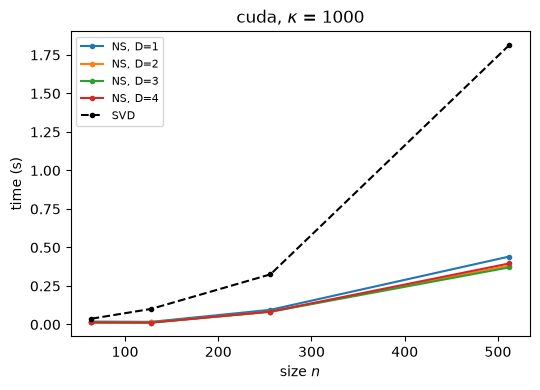

In [3]:
import os

cond_plot = 1e3  # condition number shown in the time-vs-size panel and the tables
n_plot = 512     # size shown in the time-vs-cond panel and tables
fig, axs = plt.subplots(1, len(res["cfg"].devices), figsize=(5.5 * len(res["cfg"].devices), 4), squeeze=False)
for ax, device in zip(axs[0], res["cfg"].devices):
    plots.plot_time_vs_size(res, device, cond_plot, ax=ax)
    ax.set_yscale("linear")
    ax.set_xscale("linear")
fig.tight_layout()
os.makedirs("../figures", exist_ok=True)
fig.savefig(f"../figures/cpwl_{cfg.profile}_time_vs_size_cond{cond_plot:g}.pdf", bbox_inches="tight")

time (s), median ± std over 5 matrices: cuda, n = 512
cond    D=1              D=2              D=3              D=4              SVD          
2       0.151 ± 0.00098  0.139 ± 0.00078  0.151 ± 0.0075   0.137 ± 0.00055  1.64 ± 0.012 
5       0.239 ± 0.0009   0.203 ± 0.00056  0.214 ± 0.00042  0.213 ± 0.00068  1.57 ± 0.012 
10      0.365 ± 0.0033   0.318 ± 0.0013   0.324 ± 0.0009   0.325 ± 0.0012   1.62 ± 0.0098
100     0.423 ± 0.0015   0.368 ± 0.00067  0.37 ± 0.001     0.38 ± 0.0085    1.68 ± 0.011 
1000    0.442 ± 0.0027   0.381 ± 0.0034   0.385 ± 0.0022   0.398 ± 0.0019   1.82 ± 0.014 
10000   0.502 ± 0.0047   0.433 ± 0.0013   0.418 ± 0.00089  0.457 ± 0.0015   2.03 ± 0.015 
100000  0.542 ± 0.0035   0.472 ± 0.0029   0.466 ± 0.0022   0.475 ± 0.0022   2.24 ± 0.018 
1e+06   0.612 ± 0.0024   0.522 ± 0.0022   0.514 ± 0.002    0.551 ± 0.00094  2.44 ± 0.019 



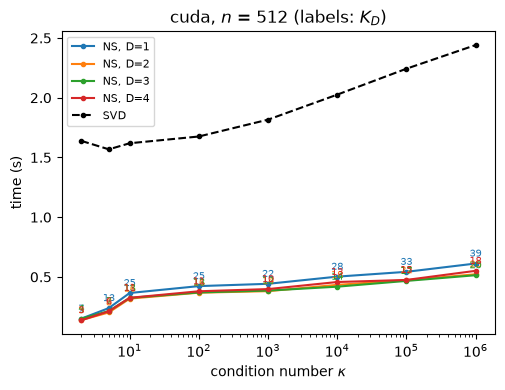

In [22]:
fig, axs = plt.subplots(1, len(res["cfg"].devices), figsize=(5.5 * len(res["cfg"].devices), 4), squeeze=False)
for ax, device in zip(axs[0], res["cfg"].devices):
    plots.plot_time_vs_cond(res, device, n_plot, ax=ax)
fig.tight_layout()
ax.set_yscale("linear")
for device in res["cfg"].devices:
    cond_table(res, device, n_plot)
    print()

## Tables
Time and speedup over the SVD-based evaluation at `cond_plot`, then, for every condition number $\kappa$, the relative Frobenius error against the exact CPWL operator, evaluation time, number of internal sign-map calls, and the largest iteration count any of those calls needed to reach $\varepsilon$, one row per degree $D$.

In [6]:
for device in res["cfg"].devices:
    time_table(res, device, cond_plot)
    print()
    speedup_table(res, device, cond_plot)
    print()
    for size in res["cfg"].sizes:
        cpwl_results_table(res, device, size, cond_plot)
    # for cond in cfg.conds:
    #     cpwl_results_table(res, device, 64, cond)
    #     print()

time (s), median ± std over 5 matrices: cuda, cond = 1000
n    D=1              D=2              D=3               D=4               SVD            
64   0.0172 ± 0.0023  0.0143 ± 0.0024  0.0142 ± 0.0012   0.0137 ± 0.00035  0.0379 ± 0.0076
128  0.0188 ± 0.0059  0.0145 ± 0.0036  0.0129 ± 0.00064  0.0124 ± 0.00035  0.102 ± 0.0011 
256  0.0931 ± 0.0014  0.0823 ± 0.0011  0.0828 ± 0.0034   0.0833 ± 0.001    0.326 ± 0.0024 
512  0.44 ± 0.0025    0.38 ± 0.0021    0.37 ± 0.0097     0.396 ± 0.0017    1.81 ± 0.018   

speedup over the SVD (median times): cuda, cond = 1000
n    D=1    D=2    D=3    D=4  
64   2.20x  2.64x  2.67x  2.77x
128  5.41x  7.00x  7.87x  8.19x
256  3.50x  3.96x  3.93x  3.91x
512  4.13x  4.77x  4.90x  4.58x

CPWL operator (leaky_clip), tolerance eps = 1e-10, mean/max over 5 matrices: cuda, n = 64, cond = 1000
     rel. Frobenius error  time      # sign calls  max K
D=1  1.69e-14              17.21 ms  2.0           22   
D=2  6.41e-14              14.33 ms  2.0           14